# White dwarf habitable-zone and exomoon-stability plots

For a planet in the white dwarf habitable zone, checking whether there is enough space for a moon between the Roche limit and one third of the Hill radius.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


# White dwarf habitable zone + simple exomoon stability 


# Constants
Msun = 1.989e30       # kg
Rsun = 6.957e8        # m
AU = 1.496e11         # m
Lsun = 3.828e26       # W
sigma = 5.671e-8      # W m^-2 K^-4

Mjup = 1.898e27       # kg
Rjup = 7.1492e7       # m

# Assumptions
A = 0.3               # Bond albedo
eps = 1.0             # emissivity

T_inner = 373.0       # K; simple inner HZ edge
T_outer = 273.0       # K; simple outer HZ edge

Mwd_ref = 0.6         # Msun; representative WD mass curve
Mp_ref = 1.0          # Mjup; representative giant planet mass
Rp_ref = 1.0          # Rjup; representative giant planet radius

rho_moon = 3340.0     # kg/m^3; rocky Moon-like density
roche_C = 2.44        # fluid Roche coefficient

# Functions
def hz_distance_AU(L_W, T_K):
    """
    Rearranged equilibrium temperature equation.
    Planet-WD distance where equilibrium temperature is T_K.
    WD luminosity is L_W.
    Returns AU.
    """
    return np.sqrt(
        L_W * (1 - A)
        / (16 * np.pi * eps * sigma * T_K**4)
    ) / AU


def wd_radius_nauenberg_m(Mwd_Msun):
    """
    Nauenberg zero-temperature white dwarf mass-radius relation.
    Use when luminosity is not given but Mwd and Teff are available.
    Built upon zero temp approximation, which can be used for WD.
    Returns metres.
    """
    Mch = 1.44
    x = Mwd_Msun / Mch

    return (
        0.0126 * Rsun
        * np.sqrt(1 - x**(4 / 3))
        / x**(1 / 3)
    )


def logL_from_Mwd_Teff(Mwd_Msun, Teff_K):
    """
    Estimate log10(L/Lsun) from WD mass and effective temperature.
    """
    Rwd = wd_radius_nauenberg_m(Mwd_Msun)
    L = 4 * np.pi * Rwd**2 * sigma * Teff_K**4

    return np.log10(L / Lsun)


def wd_Teff_from_logL(Mwd_Msun, logL):
    """
    Estimate WD effective temperature from mass and log10(L/Lsun).

    Uses:
        L = 4 pi Rwd^2 sigma Teff^4

    with Rwd from the Nauenberg mass-radius relation.
    """
    Rwd = wd_radius_nauenberg_m(Mwd_Msun)
    L = 10**logL * Lsun

    return (L / (4 * np.pi * Rwd**2 * sigma))**0.25


def logL_needed_for_HZ_temperature(a_AU, T_K):
    """
    Luminosity needed for a body at distance a_AU to have equilibrium temperature T_K.

    Rearranged from:
        T_eq = [L(1-A)/(16 pi eps sigma a^2)]^(1/4)
    """
    a_m = a_AU * AU

    L_needed = (
        16 * np.pi * eps * sigma * a_m**2 * T_K**4
        / (1 - A)
    )

    return np.log10(L_needed / Lsun)


def get_logL(obj):
    """
    Use logL directly if supplied. Otherwise estimate it from Mwd and Teff.
    """
    if "logL" in obj and obj["logL"] is not None:
        return obj["logL"]

    return logL_from_Mwd_Teff(
        obj["Mwd_Msun"],
        obj["Teff_K"]
    )


def planet_density_kgm3(Mp_Mjup, Rp_Rjup):
    """
    Mean density of the giant planet.
    """
    Mp = Mp_Mjup * Mjup
    Rp = Rp_Rjup * Rjup

    return Mp / ((4 / 3) * np.pi * Rp**3)


def moon_roche_limit_AU(Mp_Mjup, Rp_Rjup):
    """
    Roche limit for a moon orbiting a planet.

    R_roche = C Rp (rho_p / rho_moon)^(1/3)

    Returns AU.
    """
    rho_p = planet_density_kgm3(Mp_Mjup, Rp_Rjup)
    Rp_AU = Rp_Rjup * Rjup / AU

    return roche_C * Rp_AU * (rho_p / rho_moon)**(1 / 3)


def hill_radius_AU(a_planet_AU, Mp_Mjup, Mwd_Msun):
    """
    Hill radius of a planet orbiting a white dwarf.
    Returns AU.
    """
    return (
        a_planet_AU
        * ((Mp_Mjup * Mjup) / (3 * Mwd_Msun * Msun))**(1 / 3)
    )


def stable_moon_width_Rjup(a_planet_AU, Mp_Mjup, Rp_Rjup, Mwd_Msun):
    """
    Allowed moon-orbit width in Jupiter radii.

    Stable moon condition:
        max(R_roche, Rp) < a_moon < RH/3

    Width:
        Delta a_moon = RH/3 - max(R_roche, Rp)

    Positive width means stable moon orbits are possible.
    """
    R_roche = moon_roche_limit_AU(Mp_Mjup, Rp_Rjup)
    Rp_AU = Rp_Rjup * Rjup / AU

    inner_limit = max(R_roche, Rp_AU)
    outer_limit = hill_radius_AU(a_planet_AU, Mp_Mjup, Mwd_Msun) / 3

    return (outer_limit - inner_limit) * AU / Rjup


In [2]:
# Luminosity range
logL_grid = np.linspace(-6, -1, 700)
L_grid = 10**logL_grid * Lsun

# HZ boundaries for Figure 1
a_inner = hz_distance_AU(L_grid, T_inner)
a_outer = hz_distance_AU(L_grid, T_outer)
a_mid = np.sqrt(a_inner * a_outer)

# Exomoon-stability curves for Figure 2
stable_width_inner = np.array([
    stable_moon_width_Rjup(a, Mp_ref, Rp_ref, Mwd_ref)
    for a in a_inner
])

stable_width_mid = np.array([
    stable_moon_width_Rjup(a, Mp_ref, Rp_ref, Mwd_ref)
    for a in a_mid
])

stable_width_outer = np.array([
    stable_moon_width_Rjup(a, Mp_ref, Rp_ref, Mwd_ref)
    for a in a_outer
])

# objects for plot
# If logL is known, add "logL": value.
# If logL is not known, provide Mwd_Msun and Teff_K, and Nauenberg + Stefan-Boltzmann used.
objects = [
    {
        "name": "WD 1856+534 b",
        "a_AU": 0.0204,
        "Mwd_Msun": 0.518,
        "Teff_K": 4700.0,
        "Mp_Mjup": 13.8,       
        "Rp_Rjup": 0.94,
        "color": "gold",
        "marker": "o"
    },
    {
        "name": "Helix Nebula b candidate",
        "a_AU": 0.034,
        "Mwd_Msun": 0.65,
        "Teff_K": 4970.0,
        "Mp_Mjup": 1.0,       # mass unknown; representative value used
        "Rp_Rjup": 0.21,
        "color": "royalblue",
        "marker": "o"
    }
]

# ideal point: a representative giant planet in the middle of the HZ
ideal_logL = -2.5
ideal_L = 10**ideal_logL * Lsun
ideal_a_inner = hz_distance_AU(ideal_L, T_inner)
ideal_a_outer = hz_distance_AU(ideal_L, T_outer)
ideal_a = np.sqrt(ideal_a_inner * ideal_a_outer)

objects.append({
    "name": "Ideal HZ giant planet",
    "a_AU": ideal_a,
    "logL": ideal_logL,
    "Mwd_Msun": Mwd_ref,
    "Mp_Mjup": Mp_ref,
    "Rp_Rjup": Rp_ref,
    "color": "limegreen",
    "marker": "*"
})

# Compute derived values for plotted objects
for obj in objects:
    obj["logL"] = get_logL(obj)
    obj["stable_width_Rjup"] = stable_moon_width_Rjup(
        a_planet_AU=obj["a_AU"],
        Mp_Mjup=obj["Mp_Mjup"],
        Rp_Rjup=obj["Rp_Rjup"],
        Mwd_Msun=obj["Mwd_Msun"]
    )

print("Assumptions")
print("-----------")
print(f"Bond albedo A              = {A}")
print(f"Emissivity eps             = {eps}")
print(f"HZ temperature range       = {T_outer:.0f}-{T_inner:.0f} K")
print(f"Reference WD mass          = {Mwd_ref:.2f} Msun")
print(f"Reference planet mass      = {Mp_ref:.2f} Mjup")
print(f"Reference planet radius    = {Rp_ref:.2f} Rjup")
print(f"Moon density               = {rho_moon:.0f} kg/m^3")
print(f"Roche coefficient          = {roche_C}")
print()

print("Objects")
print("-------")
for obj in objects:
    print(obj["name"])
    print(f"  log10(L/Lsun)       = {obj['logL']:.3f}")
    print(f"  planet-WD distance  = {obj['a_AU']:.4f} AU")
    print(f"  stable moon width   = {obj['stable_width_Rjup']:.2f} Rjup")
    print()


Assumptions
-----------
Bond albedo A              = 0.3
Emissivity eps             = 1.0
HZ temperature range       = 273-373 K
Reference WD mass          = 0.60 Msun
Reference planet mass      = 1.00 Mjup
Reference planet radius    = 1.00 Rjup
Moon density               = 3340 kg/m^3
Roche coefficient          = 2.44

Objects
-------
WD 1856+534 b
  log10(L/Lsun)       = -3.988
  planet-WD distance  = 0.0204 AU
  stable moon width   = -1.31 Rjup

Helix Nebula b candidate
  log10(L/Lsun)       = -4.013
  planet-WD distance  = 0.0340 AU
  stable moon width   = 0.12 Rjup

Ideal HZ giant planet
  log10(L/Lsun)       = -2.500
  planet-WD distance  = 0.0358 AU
  stable moon width   = 0.27 Rjup



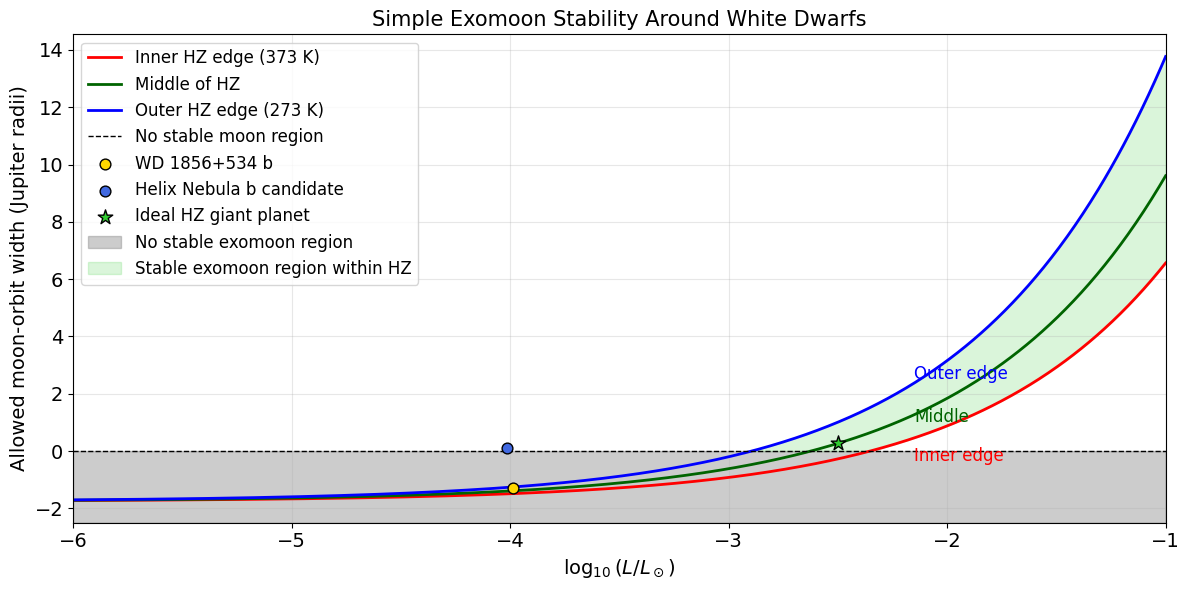

In [7]:
# Figure 2: Simple exomoon-stability plot
fig2, ax2 = plt.subplots(figsize=(12, 6))

ax2.plot(
    logL_grid,
    stable_width_inner,
    color="red",
    linewidth=2,
    label="Inner HZ edge (373 K)"
)

ax2.plot(
    logL_grid,
    stable_width_mid,
    color="darkgreen",
    linewidth=2,
    label="Middle of HZ"
)

ax2.plot(
    logL_grid,
    stable_width_outer,
    color="blue",
    linewidth=2,
    label="Outer HZ edge (273 K)"
)

ax2.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
    label="No stable moon region"
)

# Mark the HZ edge curves directly on the plot
idx_label = np.argmin(np.abs(logL_grid - (-2.2)))
ax2.annotate(
    "Inner edge",
    (logL_grid[idx_label], stable_width_inner[idx_label]),
    xytext=(8, -14),
    textcoords="offset points",
    fontsize=12,
    color="red"
)
ax2.annotate(
    "Outer edge",
    (logL_grid[idx_label], stable_width_outer[idx_label]),
    xytext=(8, 8),
    textcoords="offset points",
    fontsize=12,
    color="blue"
)
ax2.annotate(
    "Middle",
    (logL_grid[idx_label], stable_width_mid[idx_label]),
    xytext=(8, -2),
    textcoords="offset points",
    fontsize=12,
    color="darkgreen"
)

for obj in objects:
    ax2.scatter(
        obj["logL"],
        obj["stable_width_Rjup"],
        color=obj["color"],
        marker=obj["marker"],
        edgecolor="black",
        s=120 if obj["marker"] == "*" else 60,
        zorder=10,
        label=obj["name"]
    )

ymin, ymax = ax2.get_ylim()

ax2.fill_between(
    logL_grid,
    ymin,
    0,
    color="grey",
    alpha=0.4,
    label="No stable exomoon region"
)

ax2.set_ylim(ymin, ymax)

green_lower = np.maximum(stable_width_inner, 0)

ax2.fill_between(
    logL_grid,
    green_lower,
    stable_width_outer,
    where=stable_width_outer > green_lower,
    color="limegreen",
    alpha=0.18,
    label="Stable exomoon region within HZ"
)

ax2.set_xlabel(r"$\log_{10}(L/L_\odot)$", fontsize=14)
ax2.set_ylabel("Allowed moon-orbit width (Jupiter radii)", fontsize=14)
ax2.set_title("Simple Exomoon Stability Around White Dwarfs", fontsize=15)
ax2.set_xlim(-6, -1)

ax2.tick_params(axis='both', which='major', labelsize=14)

ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=12, loc="upper left")

fig2.tight_layout()
plt.show()


As the white dwarf cools over long timescales - ideal is favourable.

* Figure suggests that the systems shown here are not strong habitable-exomoon cases under the simplified assumptions.
* WD 1856+534 b appears dynamically unfavourable for stable moons, while the Helix Nebula candidate is marginal and does not sit clearly within the adopted habitable-zone model.

In [13]:
# WD effective temperature estimates for the ideal HZ regime

# Current ideal point used above
Teff_current_ideal = wd_Teff_from_logL(
    Mwd_ref,
    ideal_logL
)

print("Current ideal point")
print("-------------------")
print(f"log10(L/Lsun) = {ideal_logL:.2f}")
print(f"Estimated WD Teff = {Teff_current_ideal:.0f} K")
print()

# Longer-lived illustrative case: fixed orbit at 0.012 AU
# what WD Teff range gives 273-373 K
a_long_lived = 0.036  # AU

logL_hot_edge = logL_needed_for_HZ_temperature(
    a_long_lived,
    T_inner
)

logL_cool_edge = logL_needed_for_HZ_temperature(
    a_long_lived,
    T_outer
)

Teff_hot_edge = wd_Teff_from_logL(
    Mwd_ref,
    logL_hot_edge
)

Teff_cool_edge = wd_Teff_from_logL(
    Mwd_ref,
    logL_cool_edge
)

print("Longer-lived illustrative HZ regime")
print("------------------------------------")
print(f"Planet/exomoon orbit = {a_long_lived:.3f} AU")
print(f"Hot / inner HZ edge:  T_eq = {T_inner:.0f} K")
print(f"  log10(L/Lsun) = {logL_hot_edge:.3f}")
print(f"  WD Teff       = {Teff_hot_edge:.0f} K")
print()
print(f"Cool / outer HZ edge: T_eq = {T_outer:.0f} K")
print(f"  log10(L/Lsun) = {logL_cool_edge:.3f}")
print(f"  WD Teff       = {Teff_cool_edge:.0f} K")
print()
print("Interpretation:")
print(
    "At 0.036 AU, the object is in this simple HZ while the WD cools "
    f"from about {Teff_hot_edge:.0f} K to {Teff_cool_edge:.0f} K."
)

Current ideal point
-------------------
log10(L/Lsun) = -2.50
Estimated WD Teff = 11567 K

Longer-lived illustrative HZ regime
------------------------------------
Planet/exomoon orbit = 0.036 AU
Hot / inner HZ edge:  T_eq = 373 K
  log10(L/Lsun) = -2.224
  WD Teff       = 13561 K

Cool / outer HZ edge: T_eq = 273 K
  log10(L/Lsun) = -2.766
  WD Teff       = 9925 K

Interpretation:
At 0.036 AU, the object is in this simple HZ while the WD cools from about 13561 K to 9925 K.
